In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
## reading our closing files which is combined_weekly_dataset
## reading our predicted label regime_label_k
## reading our predicted supervised labels

## Read core files
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet")
'''supervised_predictions = pd.read_parquet("/work/master_supervised_test_predictions.parquet")'''
supervised_predictions = pd.read_parquet("master_supervised_predictions.parquet")
combined_weekly = pd.read_parquet("combined_weekly_dataset.parquet")

# Make sure indexes are datetime + sorted
for df in [regime_df, supervised_predictions, combined_weekly]:
    df.index = pd.to_datetime(df.index)

regime_df = regime_df.sort_index()
supervised_predictions = supervised_predictions.sort_index()
combined_weekly = combined_weekly.sort_index()

print("regime_df shape:", regime_df.shape)
print("supervised_predictions shape:", supervised_predictions.shape)
print("combined_weekly shape:", combined_weekly.shape)

print("\nregime_df columns:")
print(regime_df.columns.tolist())

print("\nsupervised_predictions columns:")
print(supervised_predictions.columns.tolist())

print("\ncombined_weekly columns:")
print(combined_weekly.columns.tolist())

regime_df shape: (1055, 27)
supervised_predictions shape: (456, 39)
combined_weekly shape: (1633, 31)

regime_df columns:
['global_vol', 'vol_slope', 'vov', 'SP500_SPY_ret', 'NASDAQ100_QQQ_ret', 'DOW_JONES_ret', 'NASDAQ100_ret', 'NIKKEI_225_ret', 'SHANGHAI_COMPOSITE_ret', 'HANG_SENG_ret', 'TREASURY_BOND_TLT_ret', 'GOLD_GLD_ret', 'usd_index_ret', 'SPY_return', 'QQQ_return', 'SPY_vol_12', 'SPY_vol_4', 'SPY_momentum_12', 'VIX', 'VIX_change', 'TREASURY_10Y', 'TREASURY_2Y', 'yield_spread', 'regime', 'dataset_split', 'regime_name', 'regime_3class']

supervised_predictions columns:
['SPY_return', 'QQQ_return', 'SPY_momentum_12', 'VIX_change', 'SPY_vol_4', 'SPY_vol_12', 'yield_spread', 'SPY_return_lag1', 'SPY_return_lag2', 'SPY_return_lag3', 'SPY_return_lag4', 'SPY_return_lag5', 'VIX_change_lag1', 'VIX_change_lag2', 'VIX_change_lag3', 'VIX_change_lag4', 'VIX_change_lag5', 'yield_spread_lag1', 'yield_spread_lag2', 'yield_spread_lag3', 'yield_spread_lag4', 'yield_spread_lag5', 'SPY_vol_ratio', '

In [3]:
regime_df.index = pd.to_datetime(regime_df.index, errors="coerce")
supervised_predictions.index = pd.to_datetime(supervised_predictions.index, errors="coerce")
combined_weekly.index = pd.to_datetime(combined_weekly.index, errors="coerce")

regime_df = regime_df[~regime_df.index.isna()].copy()
supervised_predictions = supervised_predictions[~supervised_predictions.index.isna()].copy()
combined_weekly = combined_weekly[~combined_weekly.index.isna()].copy()

regime_df = regime_df[~regime_df.index.duplicated(keep="first")].sort_index()
supervised_predictions = supervised_predictions[~supervised_predictions.index.duplicated(keep="first")].sort_index()
combined_weekly = combined_weekly[~combined_weekly.index.duplicated(keep="first")].sort_index()

print("regime_df date range:", regime_df.index.min(), "to", regime_df.index.max())
print("supervised_predictions date range:", supervised_predictions.index.min(), "to", supervised_predictions.index.max())
print("combined_weekly date range:", combined_weekly.index.min(), "to", combined_weekly.index.max())

regime_df date range: 2004-11-26 00:00:00 to 2026-03-06 00:00:00
supervised_predictions date range: 2017-01-06 00:00:00 to 2026-02-13 00:00:00
combined_weekly date range: 1995-01-06 00:00:00 to 2026-04-17 00:00:00


In [4]:
backtest_df = combined_weekly.copy()

# Keep only useful unsupervised columns
unsup_cols = [col for col in ["regime", "regime_3class", "regime_name"] if col in regime_df.columns]
backtest_df = backtest_df.join(regime_df[unsup_cols], how="left")

# Add supervised model predictions
backtest_df = backtest_df.join(supervised_predictions, how="left")

# Final sort
backtest_df = backtest_df.sort_index()

print("backtest_df shape:", backtest_df.shape)
print("backtest_df date range:", backtest_df.index.min(), "to", backtest_df.index.max())
print("\nbacktest_df columns:")
print(backtest_df.columns.tolist())

print("\nRows by split in joined backtest_df:")
print(backtest_df["dataset_split"].value_counts(dropna=False))

backtest_df shape: (1633, 73)
backtest_df date range: 1995-01-06 00:00:00 to 2026-04-17 00:00:00

backtest_df columns:
['SHANGHAI_COMPOSITE', 'CVX', 'usd_index', 'GOLD_GLD', 'REAL_ESTATE_IYR', 'SLB', 'SILVER_SLV', 'CRUDE_OIL_USO', 'MATERIALS_XLB', 'ENERGY_XLE', 'FINANCIALS_XLF', 'INDUSTRIALS_XLI', 'TECH_XLK', 'CONSUMER_STAPLES_XLP', 'UTILITIES_XLU', 'HEALTHCARE_XLV', 'CONSUMER_DISCRETIONARY_XLY', 'XOM', 'DOW_JONES', 'FTSE_100', 'SP500', 'HANG_SENG', 'NIKKEI_225', 'NASDAQ100', 'EURO_STOXX_50', 'VIX', 'TREASURY_10Y', 'TREASURY_2Y', 'NASDAQ100_QQQ', 'SP500_SPY', 'TREASURY_BOND_TLT', 'regime', 'regime_3class', 'regime_name', 'SPY_return', 'QQQ_return', 'SPY_momentum_12', 'VIX_change', 'SPY_vol_4', 'SPY_vol_12', 'yield_spread', 'SPY_return_lag1', 'SPY_return_lag2', 'SPY_return_lag3', 'SPY_return_lag4', 'SPY_return_lag5', 'VIX_change_lag1', 'VIX_change_lag2', 'VIX_change_lag3', 'VIX_change_lag4', 'VIX_change_lag5', 'yield_spread_lag1', 'yield_spread_lag2', 'yield_spread_lag3', 'yield_spread_

In [5]:
# Keep only rows where 2-layer supervised prediction exists
phuc_bt = backtest_df.dropna(subset=["phuc_2layer_pred", "dataset_split"]).copy()

phuc_val = phuc_bt[phuc_bt["dataset_split"] == "validation"].copy()
phuc_test = phuc_bt[phuc_bt["dataset_split"] == "test"].copy()

print("phuc_bt shape:", phuc_bt.shape)
print("phuc_bt date range:", phuc_bt.index.min(), "to", phuc_bt.index.max())

print("\nValidation shape:", phuc_val.shape)
print("Validation date range:", phuc_val.index.min(), "to", phuc_val.index.max())

print("\nTest shape:", phuc_test.shape)
print("Test date range:", phuc_test.index.min(), "to", phuc_test.index.max())

print("\n2-layer signal columns preview:")
print(
    phuc_bt[
        [
            "dataset_split",
            "current_regime",
            "next_regime",
            "actual_next_regime",
            "persistence_pred",
            "arun_pred",
            "phuc_2layer_pred",
            "phuc_l1_pred",
            "phuc_l2_pred",
            "phuc_l1_risk_prob",
        ]
    ].head(10)
)

phuc_bt shape: (456, 73)
phuc_bt date range: 2017-01-06 00:00:00 to 2026-02-13 00:00:00

Validation shape: (148, 73)
Validation date range: 2017-01-06 00:00:00 to 2019-12-27 00:00:00

Test shape: (308, 73)
Test date range: 2020-01-03 00:00:00 to 2026-02-13 00:00:00

2-layer signal columns preview:
           dataset_split current_regime next_regime actual_next_regime  \
2017-01-06    validation        Low_Vol     Low_Vol            Low_Vol   
2017-01-13    validation        Low_Vol     Low_Vol            Low_Vol   
2017-01-20    validation        Low_Vol     Low_Vol            Low_Vol   
2017-01-27    validation        Low_Vol     Low_Vol            Low_Vol   
2017-02-03    validation        Low_Vol     Low_Vol            Low_Vol   
2017-02-10    validation        Low_Vol     Low_Vol            Low_Vol   
2017-02-17    validation        Low_Vol     Low_Vol            Low_Vol   
2017-02-24    validation        Low_Vol     Low_Vol            Low_Vol   
2017-03-03    validation        Low

In [16]:
# Build broader return series from combined_weekly prices
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "XLE": "ENERGY_XLE",
    "XLK": "TECH_XLK",
    "XLU": "UTILITIES_XLU",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLF": "FINANCIALS_XLF",
}

returns_df = pd.DataFrame(index=combined_weekly.index)
for asset_name, col in price_cols.items():
    if col in combined_weekly.columns:
        returns_df[f"{asset_name}_return"] = combined_weekly[col].pct_change()

# Add returns to backtest_df ONCE
for col in returns_df.columns:
    backtest_df[col] = returns_df[col]

print("Return columns now in backtest_df:")
print([c for c in backtest_df.columns if c.endswith("_return")])

phuc_bt = backtest_df.dropna(subset=["phuc_2layer_pred", "dataset_split"]).copy()

phuc_val = phuc_bt[phuc_bt["dataset_split"] == "validation"].copy()
phuc_test = phuc_bt[phuc_bt["dataset_split"] == "test"].copy()

Return columns now in backtest_df:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'XLE_return', 'XLK_return', 'XLU_return', 'XLP_return', 'XLV_return', 'XLF_return']


In [18]:
print("Returns df shape:", returns_df.shape)

# Safely overwrite / add return columns into phuc_bt
for col in returns_df.columns:
    phuc_bt[col] = returns_df[col]

print("\nphuc_bt shape after adding returns:", phuc_bt.shape)

print("\nAvailable return columns:")
print([c for c in phuc_bt.columns if c.endswith("_return")])

print("\nReturn preview:")
print(phuc_bt[[c for c in phuc_bt.columns if c.endswith("_return")]].head())

print("Phuc backtest shape:", phuc_bt.shape)
print(
    "\nPhuc date range:",
    phuc_bt.index.min().date(), "to", phuc_bt.index.max().date()
)

# Strategy signals from Phuc's model outputs
phuc_bt["signal_persist"] = phuc_bt["persistence_pred"]
phuc_bt["signal_2l_base"] = phuc_bt["phuc_l2_pred"]
phuc_bt["signal_2l"] = phuc_bt["phuc_2layer_pred"]

phuc_bt["signal_persist_trade"] = phuc_bt["signal_persist"].shift(1)
phuc_bt["signal_2l_base_trade"] = phuc_bt["signal_2l_base"].shift(1)
phuc_bt["signal_2l_trade"] = phuc_bt["signal_2l"].shift(1)

print(phuc_bt[
    ["signal_persist", "signal_persist_trade",
     "signal_2l", "signal_2l_trade"]
].head(10))

print("\nPersistence signal counts:")
print(phuc_bt["signal_persist"].value_counts(dropna=False))

print("\n2-layer base signal counts:")
print(phuc_bt["signal_2l_base"].value_counts(dropna=False))

print("\n2-layer final signal counts:")
print(phuc_bt["signal_2l"].value_counts(dropna=False))

print("\n2-layer tradable signal counts:")
print(phuc_bt["signal_2l_trade"].value_counts(dropna=False))

print("\nPreview Phuc signals:")
print(
    phuc_bt[
        [
            "current_regime",
            "actual_next_regime",
            "signal_persist",
            "signal_2l_base",
            "signal_2l"
        ]
    ].head(10)
)

Returns df shape: (1633, 10)

phuc_bt shape after adding returns: (456, 81)

Available return columns:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'XLE_return', 'XLK_return', 'XLU_return', 'XLP_return', 'XLV_return', 'XLF_return']

Return preview:
            SPY_return  QQQ_return  TLT_return  GLD_return  XLE_return  \
2017-01-06    0.016463    0.029119    0.014523    0.019524    0.007568   
2017-01-13   -0.000704    0.010088    0.003723    0.022013   -0.019898   
2017-01-20   -0.001365    0.000731   -0.011293    0.007355    0.002152   
2017-01-27    0.009835    0.020690   -0.002585   -0.013559   -0.004159   
2017-02-03    0.001616   -0.000954   -0.003116    0.023262   -0.011181   

            XLK_return  XLU_return  XLP_return  XLV_return  XLF_return  
2017-01-06    0.021505    0.005353    0.007929    0.029156    0.012473  
2017-01-13    0.005263   -0.006553   -0.011512   -0.000423   -0.001274  
2017-01-20    0.002820    0.002680    0.020575   -0.015228   -0.015313  
20

In [20]:
# Performance Functions

def cumulative_growth(return_series, initial_value=1.0):
    return_series = return_series.dropna()
    return initial_value * (1 + return_series).cumprod()

def annualized_return(return_series, periods_per_year=52):
    return_series = return_series.dropna()
    n_periods = len(return_series)
    if n_periods == 0:
        return np.nan
    compounded = (1 + return_series).prod()
    return compounded ** (periods_per_year / n_periods) - 1

def annualized_volatility(return_series, periods_per_year=52):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return np.nan
    return return_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(return_series, periods_per_year=52, risk_free_rate=0.0):
    return_series = return_series.dropna()
    ann_ret = annualized_return(return_series, periods_per_year)
    ann_vol = annualized_volatility(return_series, periods_per_year)
    if pd.isna(ann_vol) or ann_vol == 0:
        return np.nan
    return (ann_ret - risk_free_rate) / ann_vol

def max_drawdown(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return np.nan
    growth = (1 + return_series).cumprod()
    peak = growth.cummax()
    drawdown = growth / peak - 1
    return drawdown.min()

def summarize_performance(return_series, name, periods_per_year=52):
    return {
        "Strategy": name,
        "Annualized Return": annualized_return(return_series, periods_per_year),
        "Annualized Volatility": annualized_volatility(return_series, periods_per_year),
        "Sharpe Ratio": sharpe_ratio(return_series, periods_per_year),
        "Max Drawdown": max_drawdown(return_series)
    }

In [22]:
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "XLE": "ENERGY_XLE",
    "XLK": "TECH_XLK",
    "XLU": "UTILITIES_XLU",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLF": "FINANCIALS_XLF"
}

allocation_map_a = {
    "Low_Vol": {"SPY": 0.60, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.00},
    "Mid_Vol": {"SPY": 0.30, "QQQ": 0.20, "TLT": 0.30, "GLD": 0.20},
    "High_Vol": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_b = {
    "Low_Vol": {"SPY": 0.70, "QQQ": 0.20, "TLT": 0.10, "GLD": 0.00},
    "Mid_Vol": {"SPY": 0.50, "QQQ": 0.00, "TLT": 0.30, "GLD": 0.20},
    "High_Vol": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_c = {
    "Low_Vol": {"SPY": 0.40, "QQQ": 0.20, "XLK": 0.20, "XLE": 0.10, "TLT": 0.10},
    "Mid_Vol": {"TLT": 0.30, "GLD": 0.20, "XLU": 0.35, "XLP": 0.15},
    "High_Vol": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_d = {
    "Low_Vol": {"SPY": 0.50, "QQQ": 0.20, "XLK": 0.20, "TLT": 0.10},
    "Mid_Vol": {"TLT": 0.10, "GLD": 0.50, "XLU": 0.15, "XLP": 0.10, "XLV": 0.15},
    "High_Vol": {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

In [24]:
allocation_maps = {
    "A": allocation_map_a,
    "B": allocation_map_b,
    "C": allocation_map_c,
    "D": allocation_map_d,
}

for name, alloc_map in allocation_maps.items():
    print(f"\nAllocation Map {name}")
    for regime, weights in alloc_map.items():
        total_weight = sum(weights.values())
        print(f"{regime}: {total_weight:.2f}")


Allocation Map A
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00

Allocation Map B
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00

Allocation Map C
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00

Allocation Map D
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00


In [26]:
# Safely refresh/add all return columns into phuc_bt
for col in returns_df.columns:
    phuc_bt[col] = returns_df[col]

print("phuc_bt shape:", phuc_bt.shape)

print("\nReturn columns available in phuc_bt:")
print([c for c in phuc_bt.columns if c.endswith("_return")])

print("\nPhuc prediction columns preview:")
print(
    phuc_bt[
        [
            "current_regime",
            "actual_next_regime",
            "persistence_pred",
            "phuc_l2_pred",
            "phuc_2layer_pred",
            "phuc_l1_pred"
        ]
    ].head()
)

phuc_bt shape: (456, 87)

Return columns available in phuc_bt:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'XLE_return', 'XLK_return', 'XLU_return', 'XLP_return', 'XLV_return', 'XLF_return']

Phuc prediction columns preview:
           current_regime actual_next_regime persistence_pred phuc_l2_pred  \
2017-01-06        Low_Vol            Low_Vol          Low_Vol      Mid_Vol   
2017-01-13        Low_Vol            Low_Vol          Low_Vol      Mid_Vol   
2017-01-20        Low_Vol            Low_Vol          Low_Vol      Mid_Vol   
2017-01-27        Low_Vol            Low_Vol          Low_Vol      Mid_Vol   
2017-02-03        Low_Vol            Low_Vol          Low_Vol      Mid_Vol   

           phuc_2layer_pred phuc_l1_pred  
2017-01-06          Low_Vol         calm  
2017-01-13          Low_Vol         calm  
2017-01-20          Low_Vol         calm  
2017-01-27          Low_Vol         calm  
2017-02-03          Low_Vol         calm  


In [28]:
def run_allocation_backtest(
    base_df,
    signal_col,
    allocation_map,
    strategy_name,
    benchmark_spy_col="SPY_return",
    benchmark_tlt_col="TLT_return"
):
    df = base_df.copy()

    # Drop old weight / result columns if rerunning
    cols_to_drop = [c for c in df.columns if c.startswith("w_")] + [
        "strategy_return", "benchmark_spy", "benchmark_80_20",
        "strategy_growth", "spy_growth", "growth_8020"
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    def get_weights(regime):
        if pd.isna(regime):
            return {}
        if regime not in allocation_map:
            raise ValueError(f"Regime {regime} not found in allocation map")
        return allocation_map[regime]

    weights_df = df[signal_col].map(get_weights).apply(pd.Series).fillna(0.0)
    weights_df = weights_df.add_prefix("w_")

    df = pd.concat([df, weights_df], axis=1)

    weight_cols = list(weights_df.columns)

    # Ensure needed return columns exist
    for col in weight_cols:
        asset_name = col.replace("w_", "")
        return_col = f"{asset_name}_return"
        if return_col not in df.columns:
            df[return_col] = np.nan

    # Check weight sums
    weight_sums = df[weight_cols].sum(axis=1)
    if not np.allclose(weight_sums.dropna(), 1.0, atol=1e-8):
        print(f"Warning: some {strategy_name} weights do not sum to 1.0")
        print(weight_sums.value_counts())

    # Re-scale weights across available assets
    strategy_returns = []

    for _, row in df.iterrows():
        row_return = 0.0
        valid_weights = {}

        for col in weight_cols:
            asset_name = col.replace("w_", "")
            return_col = f"{asset_name}_return"

            if return_col in df.columns and pd.notna(row[return_col]):
                valid_weights[asset_name] = row[col]

        if len(valid_weights) == 0:
            strategy_returns.append(0.0)
            continue

        total_weight = sum(valid_weights.values())
        if total_weight == 0:
            strategy_returns.append(0.0)
            continue

        for asset_name, w in valid_weights.items():
            return_col = f"{asset_name}_return"
            row_return += (w / total_weight) * row[return_col]

        strategy_returns.append(row_return)

    df["strategy_return"] = strategy_returns

    # Benchmarks
    df["benchmark_spy"] = df[benchmark_spy_col]
    df["benchmark_80_20"] = 0.80 * df[benchmark_spy_col] + 0.20 * df[benchmark_tlt_col]

    # Growth series
    df["strategy_growth"] = cumulative_growth(df["strategy_return"])
    df["spy_growth"] = cumulative_growth(df["benchmark_spy"])
    df["growth_8020"] = cumulative_growth(df["benchmark_80_20"])

    summary = pd.DataFrame([
        summarize_performance(df["strategy_return"], strategy_name),
        summarize_performance(df["benchmark_spy"], f"Buy & Hold SPY ({strategy_name})"),
        summarize_performance(df["benchmark_80_20"], f"80/20 SPY-TLT ({strategy_name})")
    ])

    return df, summary

In [30]:
results = {}

allocation_tests = {
    "Current": allocation_map_a,
    "Aggressive Bull": allocation_map_b,
    "Sector Tilt": allocation_map_c,
    "Defensive Rotation": allocation_map_d,
}

# Build master strategy signals

# Unsupervised baseline: use observed regime, shifted forward for trading
phuc_bt["signal_unsup"] = phuc_bt["regime_name"]
phuc_bt["signal_unsup_trade"] = phuc_bt["signal_unsup"].shift(1)

# Persistence baseline: exported prediction, shifted forward for trading
phuc_bt["signal_persist"] = phuc_bt["persistence_pred"]
phuc_bt["signal_persist_trade"] = phuc_bt["signal_persist"].shift(1)

# Arun direct supervised model: exported prediction, shifted forward for trading
phuc_bt["signal_arun"] = phuc_bt["arun_pred"]
phuc_bt["signal_arun_trade"] = phuc_bt["signal_arun"].shift(1)

# Phuc final 2-layer model: exported prediction, shifted forward for trading
phuc_bt["signal_phuc"] = phuc_bt["phuc_2layer_pred"]
phuc_bt["signal_phuc_trade"] = phuc_bt["signal_phuc"].shift(1)

# Re-split AFTER creating signal columns
phuc_val = phuc_bt[phuc_bt["dataset_split"] == "validation"].copy()
phuc_test = phuc_bt[phuc_bt["dataset_split"] == "test"].copy()

# Optional sanity check
print("\nMaster signal preview:")
print(
    phuc_bt[
        [
            "regime_name",
            "actual_next_regime",
            "signal_unsup_trade",
            "signal_persist_trade",
            "signal_arun_trade",
            "signal_phuc_trade",
        ]
    ].head(10)
)


for test_name, alloc in allocation_tests.items():

    # Unsupervised baseline
    unsup_res, unsup_summary = run_allocation_backtest(
        base_df=phuc_test.dropna(subset=["signal_unsup_trade"]).copy(),
        signal_col="signal_unsup_trade",
        allocation_map=alloc,
        strategy_name=f"Unsupervised - {test_name}"
    )
    unsup_summary["Allocation Test"] = test_name
    unsup_summary["Model Type"] = "Unsupervised"

    # Persistence baseline
    persist_res, persist_summary = run_allocation_backtest(
        base_df=phuc_test.dropna(subset=["signal_persist_trade"]).copy(),
        signal_col="signal_persist_trade",
        allocation_map=alloc,
        strategy_name=f"Persistence - {test_name}"
    )
    persist_summary["Allocation Test"] = test_name
    persist_summary["Model Type"] = "Persistence"

    # Arun direct model
    arun_res, arun_summary = run_allocation_backtest(
        base_df=phuc_test.dropna(subset=["signal_arun_trade"]).copy(),
        signal_col="signal_arun_trade",
        allocation_map=alloc,
        strategy_name=f"Arun Direct - {test_name}"
    )
    arun_summary["Allocation Test"] = test_name
    arun_summary["Model Type"] = "Arun Direct"

    # Phuc 2-layer model
    phuc_res, phuc_summary = run_allocation_backtest(
        base_df=phuc_test.dropna(subset=["signal_phuc_trade"]).copy(),
        signal_col="signal_phuc_trade",
        allocation_map=alloc,
        strategy_name=f"Phuc 2-Layer - {test_name}"
    )
    phuc_summary["Allocation Test"] = test_name
    phuc_summary["Model Type"] = "Phuc 2-Layer"

    results[test_name] = {
        "unsup": (unsup_res, unsup_summary),
        "persist": (persist_res, persist_summary),
        "arun": (arun_res, arun_summary),
        "phuc": (phuc_res, phuc_summary),
    }

comparison = pd.concat(
    [results[test_name]["unsup"][1] for test_name in results] +
    [results[test_name]["persist"][1] for test_name in results] +
    [results[test_name]["arun"][1] for test_name in results] +
    [results[test_name]["phuc"][1] for test_name in results],
    ignore_index=True
)

print(comparison.round(4))


Master signal preview:
           regime_name actual_next_regime signal_unsup_trade  \
2017-01-06     Low_Vol            Low_Vol               None   
2017-01-13     Low_Vol            Low_Vol            Low_Vol   
2017-01-20     Low_Vol            Low_Vol            Low_Vol   
2017-01-27     Low_Vol            Low_Vol            Low_Vol   
2017-02-03     Low_Vol            Low_Vol            Low_Vol   
2017-02-10     Low_Vol            Low_Vol            Low_Vol   
2017-02-17     Low_Vol            Low_Vol            Low_Vol   
2017-02-24     Low_Vol            Low_Vol            Low_Vol   
2017-03-03     Low_Vol            Low_Vol            Low_Vol   
2017-03-10     Low_Vol            Low_Vol            Low_Vol   

           signal_persist_trade signal_arun_trade signal_phuc_trade  
2017-01-06                 None              None              None  
2017-01-13              Low_Vol           Low_Vol           Low_Vol  
2017-01-20              Low_Vol           Low_Vol           L

In [32]:
comparison_sorted = comparison.sort_values(
    by=["Model Type", "Sharpe Ratio", "Annualized Return"],
    ascending=[True, False, False]
)

print(comparison_sorted.round(4))

                                             Strategy  Annualized Return  \
25             Buy & Hold SPY (Arun Direct - Current)             0.1375   
28     Buy & Hold SPY (Arun Direct - Aggressive Bull)             0.1375   
31         Buy & Hold SPY (Arun Direct - Sector Tilt)             0.1375   
34  Buy & Hold SPY (Arun Direct - Defensive Rotation)             0.1375   
26              80/20 SPY-TLT (Arun Direct - Current)             0.1068   
29      80/20 SPY-TLT (Arun Direct - Aggressive Bull)             0.1068   
32          80/20 SPY-TLT (Arun Direct - Sector Tilt)             0.1068   
35   80/20 SPY-TLT (Arun Direct - Defensive Rotation)             0.1068   
24                              Arun Direct - Current             0.0862   
27                      Arun Direct - Aggressive Bull             0.0908   
33                   Arun Direct - Defensive Rotation             0.0810   
30                          Arun Direct - Sector Tilt             0.0790   
13          

In [34]:
strategy_only = comparison[
    ~comparison["Strategy"].str.contains("Buy & Hold|80/20", regex=True)
].copy()

strategy_only_sorted = strategy_only.sort_values(
    by=["Sharpe Ratio", "Annualized Return"],
    ascending=[False, False]
)

print(strategy_only_sorted.round(4))

                             Strategy  Annualized Return  \
45  Phuc 2-Layer - Defensive Rotation             0.1260   
42         Phuc 2-Layer - Sector Tilt             0.1165   
39     Phuc 2-Layer - Aggressive Bull             0.1086   
36             Phuc 2-Layer - Current             0.0972   
9   Unsupervised - Defensive Rotation             0.0941   
21   Persistence - Defensive Rotation             0.0941   
0              Unsupervised - Current             0.0822   
12              Persistence - Current             0.0822   
24              Arun Direct - Current             0.0862   
3      Unsupervised - Aggressive Bull             0.0839   
15      Persistence - Aggressive Bull             0.0839   
27      Arun Direct - Aggressive Bull             0.0908   
6          Unsupervised - Sector Tilt             0.0781   
18          Persistence - Sector Tilt             0.0781   
33   Arun Direct - Defensive Rotation             0.0810   
30          Arun Direct - Sector Tilt   

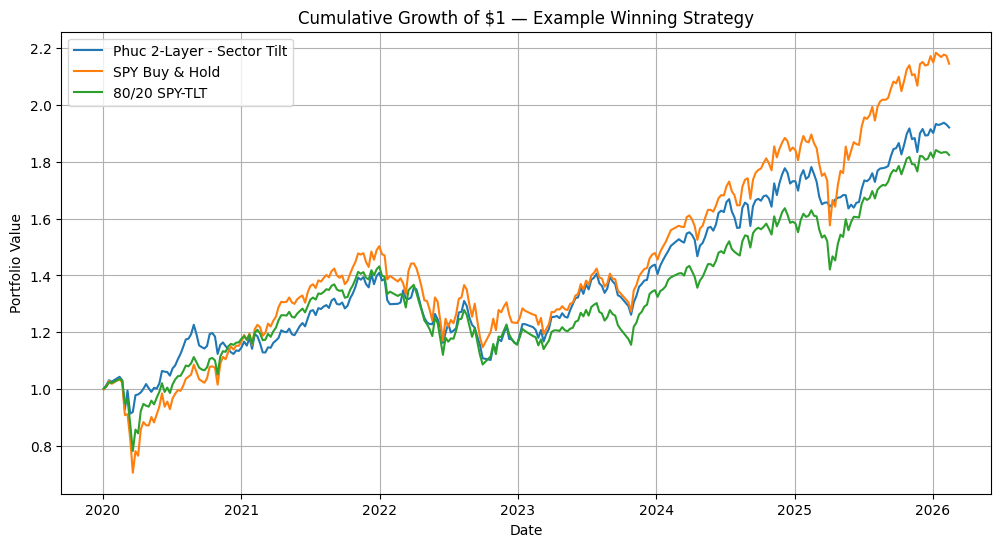

In [36]:
best_bt = results["Sector Tilt"]["phuc"][0].copy()

plt.figure(figsize=(12, 6))
plt.plot(best_bt.index, best_bt["strategy_growth"], label="Phuc 2-Layer - Sector Tilt")
plt.plot(best_bt.index, best_bt["spy_growth"], label="SPY Buy & Hold")
plt.plot(best_bt.index, best_bt["growth_8020"], label="80/20 SPY-TLT")
plt.title("Cumulative Growth of $1 — Example Winning Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

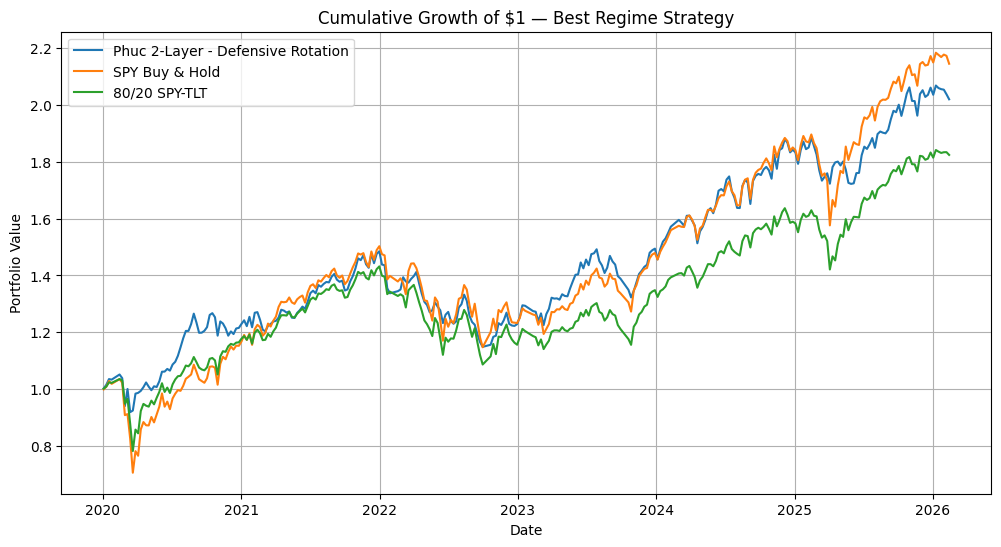

In [38]:
# Pick top-ranked strategy from strategy_only_sorted
best_row = strategy_only_sorted.iloc[0]

best_strategy = best_row["Strategy"]
best_model_type = best_row["Model Type"]
best_alloc_test = best_row["Allocation Test"]

# Map Model Type to results dictionary keys
model_key_map = {
    "Unsupervised": "unsup",
    "Persistence": "persist",
    "Arun Direct": "arun",
    "Phuc 2-Layer": "phuc"
}

best_key = model_key_map[best_model_type]
best_bt = results[best_alloc_test][best_key][0].copy()

plt.figure(figsize=(12, 6))
plt.plot(best_bt.index, best_bt["strategy_growth"], label=best_strategy)
plt.plot(best_bt.index, best_bt["spy_growth"], label="SPY Buy & Hold")
plt.plot(best_bt.index, best_bt["growth_8020"], label="80/20 SPY-TLT")
plt.title("Cumulative Growth of $1 — Best Regime Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

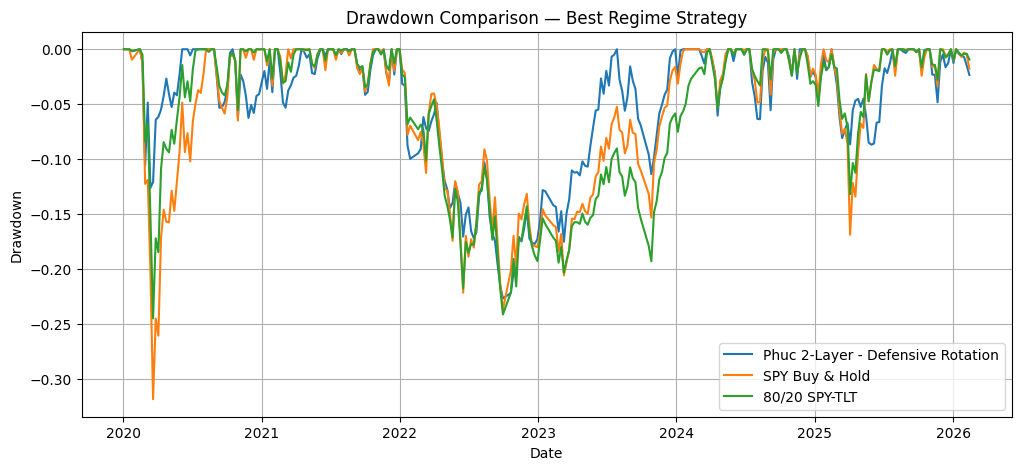

In [40]:
def compute_drawdown(return_series):
    growth = (1 + return_series.fillna(0)).cumprod()
    peak = growth.cummax()
    return growth / peak - 1

best_bt["dd_strategy"] = compute_drawdown(best_bt["strategy_return"])
best_bt["dd_spy"] = compute_drawdown(best_bt["benchmark_spy"])
best_bt["dd_8020"] = compute_drawdown(best_bt["benchmark_80_20"])

plt.figure(figsize=(12, 5))
plt.plot(best_bt.index, best_bt["dd_strategy"], label=best_strategy)
plt.plot(best_bt.index, best_bt["dd_spy"], label="SPY Buy & Hold")
plt.plot(best_bt.index, best_bt["dd_8020"], label="80/20 SPY-TLT")
plt.title("Drawdown Comparison — Best Regime Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
def build_dynamic_allocation_map(
    train_df,
    regime_col,
    asset_cols=None,
    top_n=4,
    expected_regimes=None,
    fallback_mode="overall"
):
    if asset_cols is None:
        asset_cols = [
            "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
            "XLE_return", "XLK_return", "XLU_return", "XLP_return",
            "XLV_return", "XLF_return"
        ]

    if expected_regimes is None:
        expected_regimes = ["Low_Vol", "Mid_Vol", "High_Vol"]

    allocation_map = {}

    def build_weights(df_slice):
        scores = {}
        for col in asset_cols:
            if col not in df_slice.columns:
                continue

            series = df_slice[col].dropna()
            if len(series) < 5:
                scores[col] = 0.0
                continue

            mean_ret = series.mean()
            vol = series.std()

            if pd.isna(vol) or vol == 0:
                score = 0.0
            else:
                score = mean_ret / vol

            scores[col] = max(score, 0.0)

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        selected = [(k, v) for k, v in ranked[:top_n] if v > 0]

        if not selected:
            # equal weight fallback across first top_n available assets
            available = [col for col in asset_cols if col in df_slice.columns][:top_n]
            if not available:
                return {}
            w = 1.0 / len(available)
            return {col: w for col in available}

        total_score = sum(v for _, v in selected)
        return {k: v / total_score for k, v in selected}

    # build regime-specific maps from training data
    seen_regimes = sorted(train_df[regime_col].dropna().unique())
    for regime in seen_regimes:
        regime_slice = train_df[train_df[regime_col] == regime]
        allocation_map[regime] = build_weights(regime_slice)

    # fallback map from all training data
    if fallback_mode == "overall":
        fallback_weights = build_weights(train_df)
    else:
        fallback_weights = {asset_cols[0]: 1.0} if asset_cols else {}

    # fill missing regimes
    for regime in expected_regimes:
        if regime not in allocation_map:
            allocation_map[regime] = fallback_weights.copy()

    return allocation_map

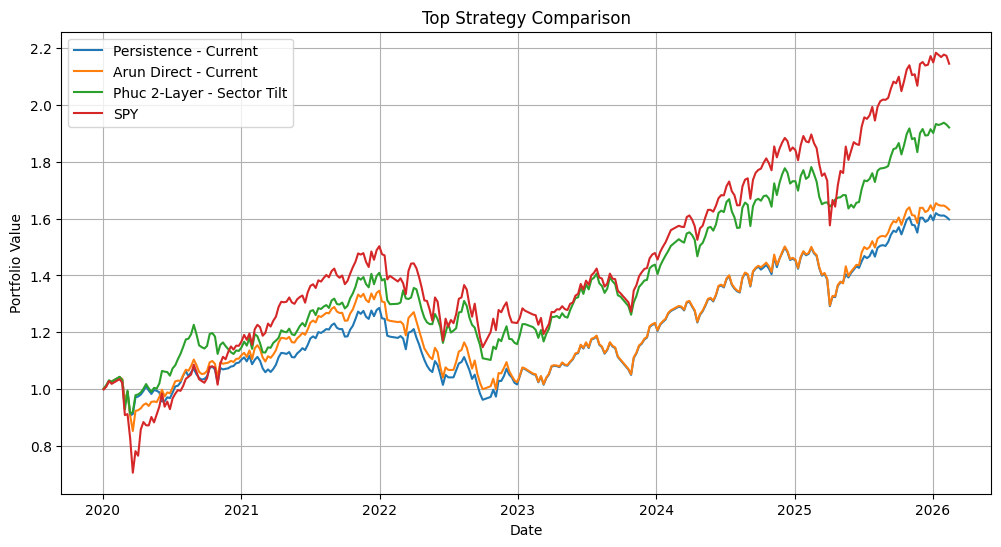

In [44]:
plot_compare = pd.DataFrame(index=phuc_test.index)

plot_compare["Persistence - Current"] = results["Current"]["persist"][0]["strategy_growth"]
plot_compare["Arun Direct - Current"] = results["Current"]["arun"][0]["strategy_growth"]
plot_compare["Phuc 2-Layer - Sector Tilt"] = results["Sector Tilt"]["phuc"][0]["strategy_growth"]
plot_compare["SPY"] = results["Current"]["phuc"][0]["spy_growth"]

plt.figure(figsize=(12, 6))
for col in plot_compare.columns:
    plt.plot(plot_compare.index, plot_compare[col], label=col)

plt.title("Top Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

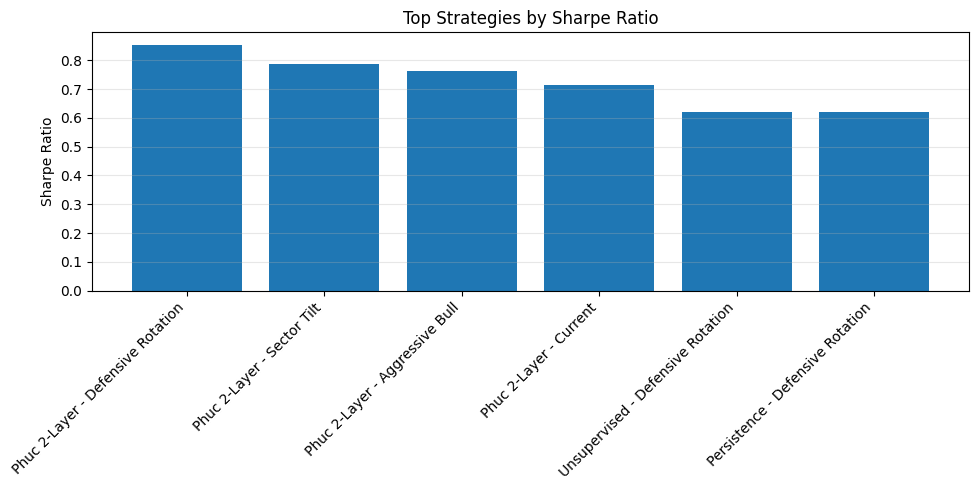

In [46]:
top_plot = strategy_only.copy().sort_values("Sharpe Ratio", ascending=False).head(6)

plt.figure(figsize=(10, 5))
plt.bar(top_plot["Strategy"], top_plot["Sharpe Ratio"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Strategies by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Keep only rows where 2-layer supervised prediction exists
phuc_bt = backtest_df.dropna(subset=["phuc_2layer_pred", "dataset_split"]).copy()

# Create trade signals from model predictions
# Use prior week's prediction to set current week's allocation
phuc_bt["signal_persist_trade"] = phuc_bt["persistence_pred"].shift(1)
phuc_bt["signal_2l_base_trade"] = phuc_bt["phuc_2layer_base_pred"].shift(1)
phuc_bt["signal_2l_trade"] = phuc_bt["phuc_2layer_pred"].shift(1)

print("phuc_bt shape:", phuc_bt.shape)
print("phuc_bt date range:", phuc_bt.index.min(), "to", phuc_bt.index.max())

print("\nTrade signal non-null counts:")
print(
    phuc_bt[
        ["signal_persist_trade", "signal_2l_base_trade", "signal_2l_trade"]
    ].notna().sum()
)

# Split validation/test
phuc_val = phuc_bt[phuc_bt["dataset_split"] == "validation"].copy()
phuc_test = phuc_bt[phuc_bt["dataset_split"] == "test"].copy()

print("\nValidation shape:", phuc_val.shape)
print("Validation date range:", phuc_val.index.min(), "to", phuc_val.index.max())

print("\nTest shape:", phuc_test.shape)
print("Test date range:", phuc_test.index.min(), "to", phuc_test.index.max())

# Dynamic allocation training window:
# learn allocation map on validation, evaluate on test
phuc_train = phuc_val.copy()
phuc_dynamic_test = phuc_test.copy()

print("\nDynamic train shape:", phuc_train.shape)
print("Dynamic test shape:", phuc_dynamic_test.shape)
print("Dynamic train range:", phuc_train.index.min().date(), "to", phuc_train.index.max().date())
print("Dynamic test range:", phuc_dynamic_test.index.min().date(), "to", phuc_dynamic_test.index.max().date())

dynamic_map_persist = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_persist_trade"]),
    regime_col="signal_persist_trade",
    top_n=4
)

dynamic_map_2l_base = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_base_trade"]),
    regime_col="signal_2l_base_trade",
    top_n=4
)

dynamic_map_2l = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_trade"]),
    regime_col="signal_2l_trade",
    top_n=4
)

print("Dynamic map - Persistence")
print(dynamic_map_persist)

print("\nDynamic map - 2L Base")
print(dynamic_map_2l_base)

print("\nDynamic map - 2L Final")
print(dynamic_map_2l)

phuc_bt shape: (456, 84)
phuc_bt date range: 2017-01-06 00:00:00 to 2026-02-13 00:00:00

Trade signal non-null counts:
signal_persist_trade    455
signal_2l_base_trade    455
signal_2l_trade         455
dtype: int64

Validation shape: (148, 84)
Validation date range: 2017-01-06 00:00:00 to 2019-12-27 00:00:00

Test shape: (308, 84)
Test date range: 2020-01-03 00:00:00 to 2026-02-13 00:00:00

Dynamic train shape: (148, 84)
Dynamic test shape: (308, 84)
Dynamic train range: 2017-01-06 to 2019-12-27
Dynamic test range: 2020-01-03 to 2026-02-13
Dynamic map - Persistence
{'Low_Vol': {'XLK_return': np.float64(0.28938702751301437), 'QQQ_return': np.float64(0.26441050250670756), 'SPY_return': np.float64(0.24101367681979075), 'XLP_return': np.float64(0.20518879316048724)}, 'Mid_Vol': {'TLT_return': np.float64(0.3479434353576165), 'GLD_return': np.float64(0.31229950366360926), 'XLE_return': np.float64(0.2016804250906812), 'XLU_return': np.float64(0.138076635888093)}, 'High_Vol': {'XLK_return': n

In [50]:
available_asset_cols = [
    "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
    "XLE_return", "XLK_return", "XLU_return", "XLP_return",
    "XLV_return", "XLF_return"
]


dynamic_map_persist = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_persist_trade"]),
    regime_col="signal_persist_trade",
    asset_cols=available_asset_cols,
    top_n=2,
    expected_regimes=["Low_Vol", "Mid_Vol", "High_Vol"]
)

dynamic_map_2l_base = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_base_trade"]),
    regime_col="signal_2l_base_trade",
    asset_cols=available_asset_cols,
    top_n=2,
    expected_regimes=["Low_Vol", "Mid_Vol", "High_Vol"]
)

dynamic_map_2l = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_trade"]),
    regime_col="signal_2l_trade",
    asset_cols=available_asset_cols,
    top_n=2,
    expected_regimes=["Low_Vol", "Mid_Vol", "High_Vol"]
)


def allocation_map_to_df(allocation_map, name):
    rows = []
    for regime, weights in allocation_map.items():
        row = {"Strategy": name, "Regime": regime}
        row.update(weights)
        rows.append(row)
    return pd.DataFrame(rows)



df_persist = allocation_map_to_df(dynamic_map_persist, "Persistence")
df_2l_base = allocation_map_to_df(dynamic_map_2l_base, "2L Base")
df_2l = allocation_map_to_df(dynamic_map_2l, "2L Final")

dynamic_map_df = pd.concat([df_persist, df_2l_base, df_2l], ignore_index=True)

# Fill missing assets with 0
dynamic_map_df = dynamic_map_df.fillna(0)

# Order columns nicely
cols = ["Strategy", "Regime"] + [c for c in dynamic_map_df.columns if c not in ["Strategy", "Regime"]]
dynamic_map_df = dynamic_map_df[cols]

print(dynamic_map_df.round(3))

      Strategy    Regime  XLK_return  QQQ_return  TLT_return  GLD_return
0  Persistence   Low_Vol       0.523       0.477       0.000       0.000
1  Persistence   Mid_Vol       0.000       0.000       0.527       0.473
2  Persistence  High_Vol       0.517       0.483       0.000       0.000
3      2L Base   Low_Vol       0.525       0.475       0.000       0.000
4      2L Base   Mid_Vol       0.000       0.000       0.545       0.455
5      2L Base  High_Vol       0.517       0.483       0.000       0.000
6     2L Final   Low_Vol       0.525       0.475       0.000       0.000
7     2L Final   Mid_Vol       0.000       0.000       0.545       0.455
8     2L Final  High_Vol       0.517       0.483       0.000       0.000


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>